# Weather Data Analysis — ERA5 Reanalysis (Pune, 2023)

This notebook performs exploratory data analysis on the ERA5 reanalysis weather data for Pune, India (2023).  
Variables include surface temperature, relative humidity, wind speed, cloud cover fraction, and global horizontal irradiance (GHI).  
The data spans the full calendar year and is used as input to the multi-modal solar power forecasting model.

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────────
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from pathlib import Path

DATA = Path('../solar_forecast/data')
FIG  = Path('figures')
FIG.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

MONTHS      = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
SEASON_CLR  = {
    'Winter':       '#4472C4',
    'Pre-Monsoon':  '#ED7D31',
    'Monsoon':      '#70AD47',
    'Post-Monsoon': '#9E480E',
}

def month_to_season(m):
    if m in [12, 1, 2]:        return 'Winter'
    elif m in [3, 4, 5]:       return 'Pre-Monsoon'
    elif m in [6, 7, 8, 9]:    return 'Monsoon'
    else:                      return 'Post-Monsoon'

print('Setup complete.')

Setup complete.


## 1. Load Data

In [5]:
df = pd.read_csv(DATA / 'weather_pune_2023.csv', parse_dates=['timestamp'])
df['month']  = df['timestamp'].dt.month
df['hour']   = df['timestamp'].dt.hour
df['season'] = df['month'].map(month_to_season)

print(f'Shape : {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Date range: {df["timestamp"].min()}  →  {df["timestamp"].max()}')
df.head()

Shape : (8760, 14)
Columns: ['timestamp', 'temp_air', 'humidity', 'wind_speed', 'cloud_cover', 'ghi', 'dni_horizontal', 'dhi', 'dni', 'pressure_pa', 'precip_mm', 'month', 'hour', 'season']
Date range: 2023-01-01 00:00:00+05:30  →  2023-12-31 23:00:00+05:30


,timestamp,temp_air,humidity,wind_speed,cloud_cover,ghi,dni_horizontal,dhi,dni,pressure_pa,precip_mm,month,hour,season
0,2023-01-01 00:00:00+05:30,16.9,81,1.66,0.81,0.0,0.0,0.0,0.0,95240.0,0.0,1,0,Winter
1,2023-01-01 01:00:00+05:30,17.7,76,1.03,0.69,0.0,0.0,0.0,0.0,95220.0,0.0,1,1,Winter
2,2023-01-01 02:00:00+05:30,15.1,88,1.36,0.53,0.0,0.0,0.0,0.0,95140.0,0.0,1,2,Winter
3,2023-01-01 03:00:00+05:30,15.0,86,1.00,0.56,0.0,0.0,0.0,0.0,95120.0,0.0,1,3,Winter
4,2023-01-01 04:00:00+05:30,13.4,92,1.21,0.50,0.0,0.0,0.0,0.0,95090.0,0.0,1,4,Winter


In [6]:
df.describe().round(3)

,temp_air,humidity,wind_speed,cloud_cover,ghi,dni_horizontal,dhi,dni,pressure_pa,precip_mm,month,hour
count,8760.000,8760.000,8760.000,8760.000,8760.000,8760.000,8760.000,8760.000,8760.000,8760.000,8760.000,8760.000
mean,24.468,65.583,2.600,0.469,229.631,158.435,71.196,236.149,94838.805,0.101,6.526,11.500
std,4.923,24.379,1.583,0.421,304.231,235.417,90.344,305.436,311.921,0.582,3.448,6.923
min,9.600,9.000,0.000,0.000,0.000,0.000,0.000,0.000,93800.000,0.000,1.000,0.000
25%,21.600,46.000,1.400,0.020,0.000,0.000,0.000,0.000,94610.000,0.000,4.000,5.750
50%,23.900,71.000,2.250,0.350,9.000,1.000,8.000,10.300,94840.000,0.000,7.000,11.500
75%,27.600,88.000,3.610,0.990,472.000,286.250,131.000,506.800,95060.000,0.000,10.000,17.250
max,40.800,100.000,8.540,1.000,1024.000,860.000,456.000,932.700,95790.000,19.600,12.000,23.000


## 2. Missing Values

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(3)
mv = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
mv = mv[mv['missing_count'] > 0]
if mv.empty:
    print('No missing values found — dataset is complete.')
else:
    display(mv)

No missing values found — dataset is complete.


## 3. Monthly Boxplots — Season-Coloured

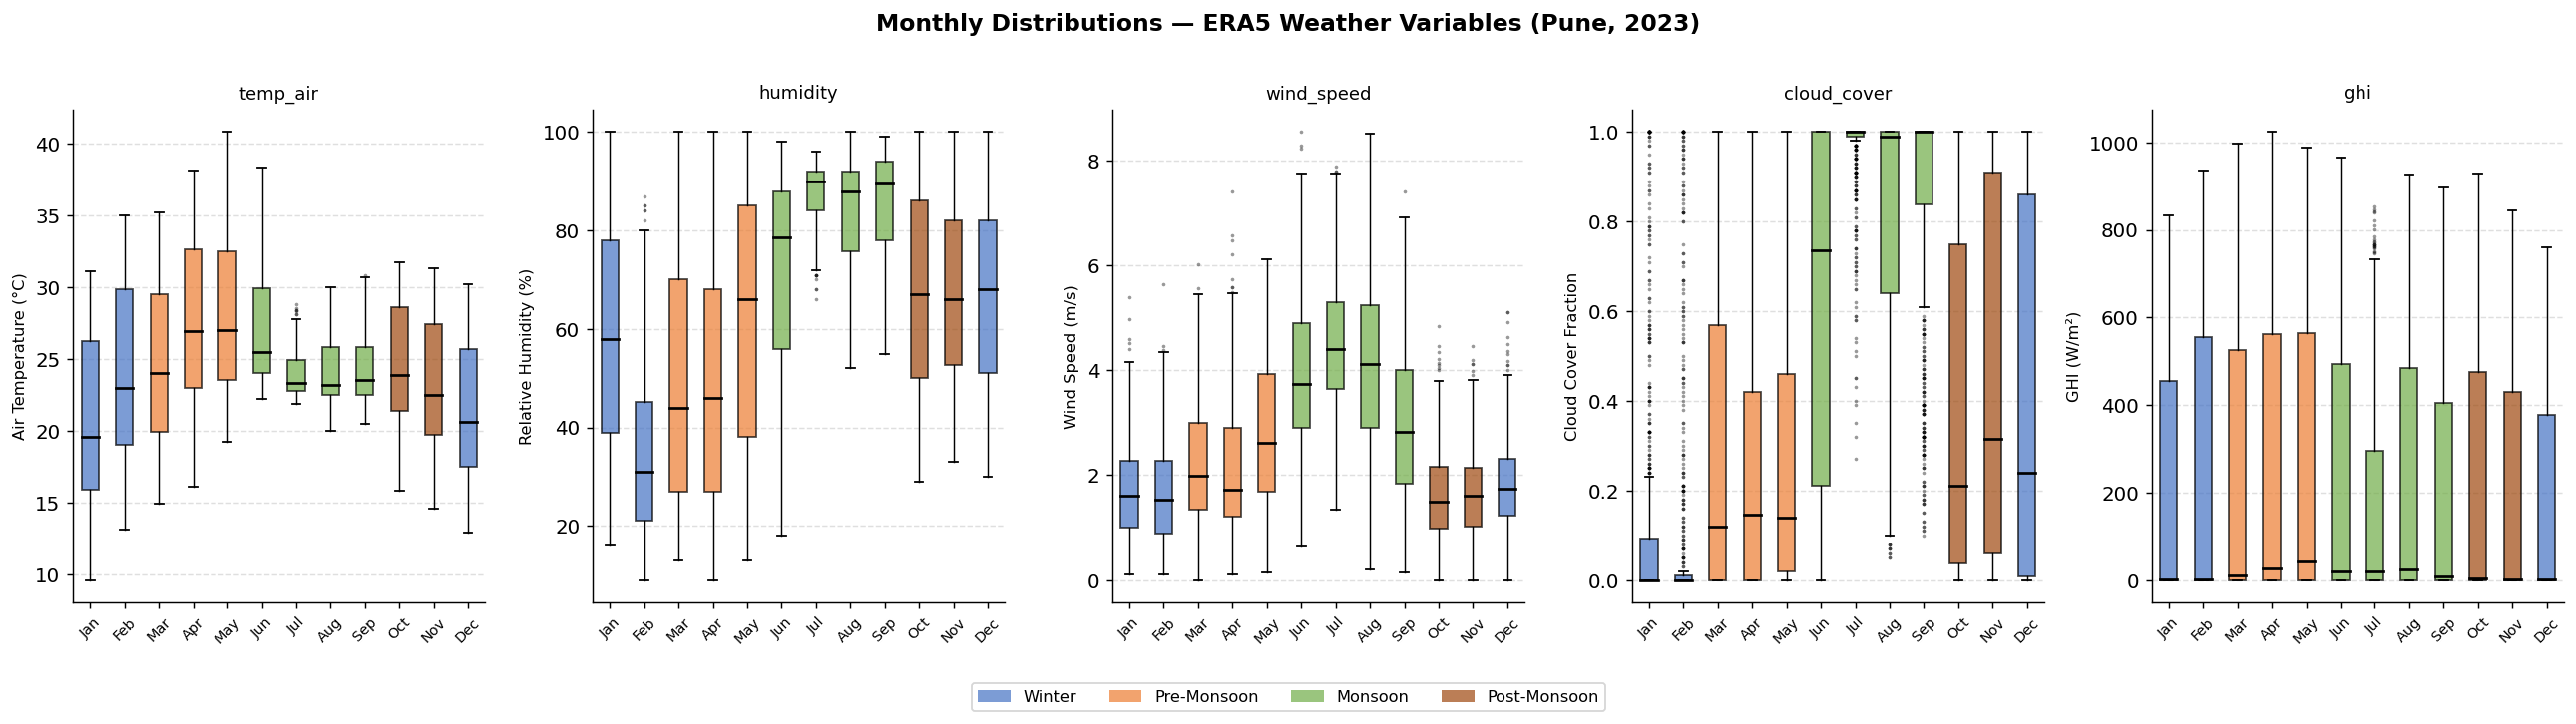

Saved: weather_monthly_boxplots.png


In [8]:
VARS = [
    ('temp_air',    'Air Temperature (°C)'),
    ('humidity',    'Relative Humidity (%)'),
    ('wind_speed',  'Wind Speed (m/s)'),
    ('cloud_cover', 'Cloud Cover Fraction'),
    ('ghi',         'GHI (W/m²)'),
]

season_for_month = {m: month_to_season(m) for m in range(1, 13)}

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Monthly Distributions — ERA5 Weather Variables (Pune, 2023)',
             fontsize=13, fontweight='bold', y=1.01)

for ax, (col, label) in zip(axes, VARS):
    groups = [df[df['month'] == m][col].dropna().values for m in range(1, 13)]
    bp = ax.boxplot(groups, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=1.5),
                    whiskerprops=dict(linewidth=0.8),
                    flierprops=dict(marker='.', markersize=2, alpha=0.4))
    for patch, m in zip(bp['boxes'], range(1, 13)):
        patch.set_facecolor(SEASON_CLR[season_for_month[m]])
        patch.set_alpha(0.7)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTHS, fontsize=8, rotation=45)
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(col, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

# Legend
handles = [mpatches.Patch(facecolor=c, alpha=0.7, label=s)
           for s, c in SEASON_CLR.items()]
fig.legend(handles=handles, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.08), fontsize=9)

plt.tight_layout()
fig.savefig(FIG / 'weather_monthly_boxplots.png', bbox_inches='tight')
plt.show()
print('Saved: weather_monthly_boxplots.png')

## 4. Pearson Correlation Heatmap

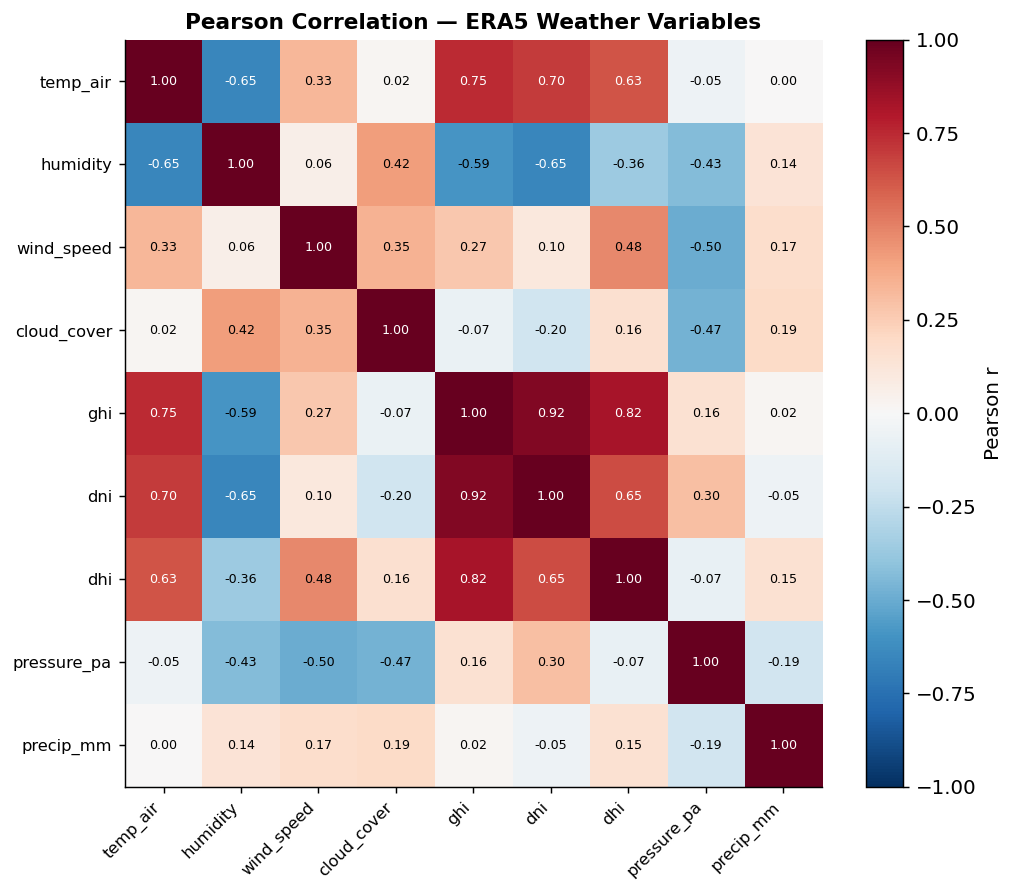

Saved: weather_correlation_heatmap.png


In [9]:
num_cols = ['temp_air', 'humidity', 'wind_speed', 'cloud_cover',
            'ghi', 'dni', 'dhi', 'pressure_pa', 'precip_mm']
num_cols = [c for c in num_cols if c in df.columns]

corr = df[num_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson r')

ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(num_cols, fontsize=9)
ax.set_title('Pearson Correlation — ERA5 Weather Variables', fontsize=12, fontweight='bold')

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        val = corr.values[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7, color=color)

plt.tight_layout()
fig.savefig(FIG / 'weather_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: weather_correlation_heatmap.png')

## 5. Diurnal Profiles by Season

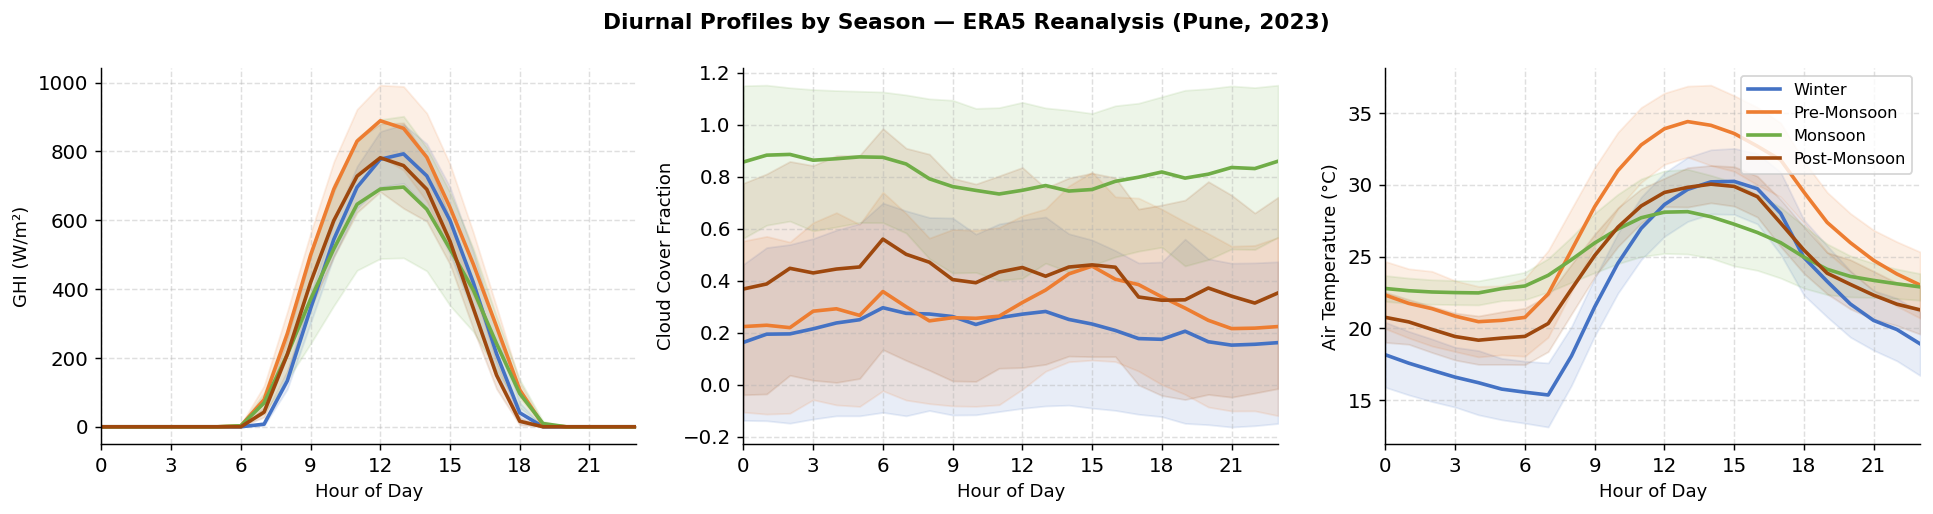

Saved: weather_diurnal_profiles.png


In [10]:
DIURNAL_VARS = [
    ('ghi',         'GHI (W/m²)'),
    ('cloud_cover', 'Cloud Cover Fraction'),
    ('temp_air',    'Air Temperature (°C)'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Diurnal Profiles by Season — ERA5 Reanalysis (Pune, 2023)',
             fontsize=12, fontweight='bold')

for ax, (col, label) in zip(axes, DIURNAL_VARS):
    for season, clr in SEASON_CLR.items():
        sub = df[df['season'] == season].groupby('hour')[col].mean()
        ax.plot(sub.index, sub.values, color=clr, linewidth=2, label=season)
        std = df[df['season'] == season].groupby('hour')[col].std()
        ax.fill_between(sub.index, sub - std, sub + std,
                        color=clr, alpha=0.12)
    ax.set_xlabel('Hour of Day', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_xticks(range(0, 24, 3))
    ax.grid(linestyle='--', alpha=0.4)
    ax.set_xlim(0, 23)

axes[-1].legend(fontsize=9, loc='upper right')
plt.tight_layout()
fig.savefig(FIG / 'weather_diurnal_profiles.png', bbox_inches='tight')
plt.show()
print('Saved: weather_diurnal_profiles.png')

## 6. Cloud Cover vs GHI — Daytime Scatter

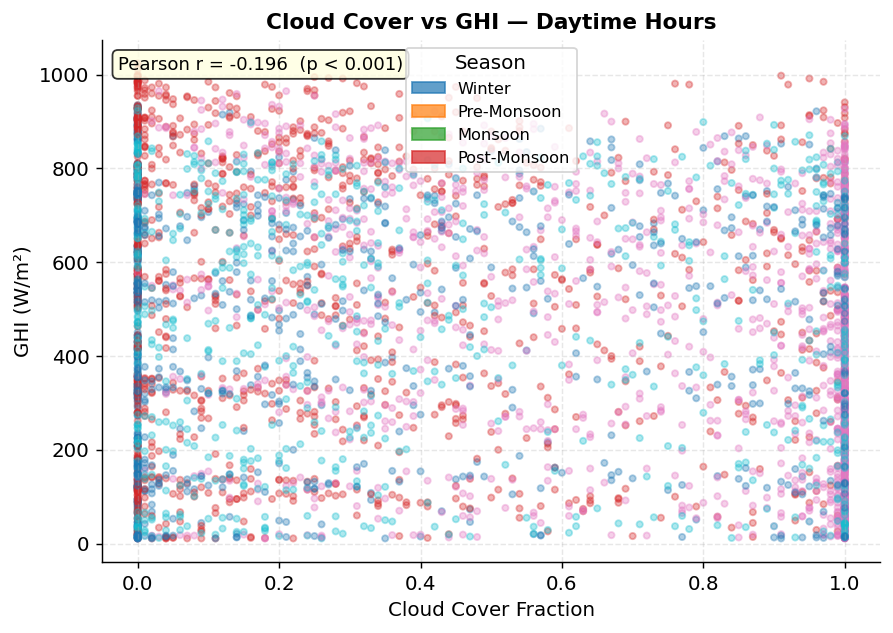

Pearson r = -0.196, p = 1.00e-38
Saved: weather_cloud_ghi_scatter.png


In [12]:
day = df[(df['ghi'] > 10) & (df['hour'].between(6, 19))].copy()
r, p = stats.pearsonr(day['cloud_cover'], day['ghi'])

# Map season to numeric index for colormap
season_order = list(SEASON_CLR.keys())
day['season_idx'] = day['season'].map({s: i for i, s in enumerate(season_order)})

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    day['cloud_cover'], day['ghi'],
    c=day['season_idx'], cmap='tab10',
    alpha=0.35, s=12, rasterized=True
)

handles = [mpatches.Patch(color=plt.cm.tab10(i / 9), alpha=0.7, label=s)
           for i, s in enumerate(season_order)]
ax.legend(handles=handles, fontsize=9, title='Season')

ax.set_xlabel('Cloud Cover Fraction', fontsize=11)
ax.set_ylabel('GHI (W/m²)', fontsize=11)
ax.set_title('Cloud Cover vs GHI — Daytime Hours', fontsize=12, fontweight='bold')
ax.text(0.02, 0.97, f'Pearson r = {r:.3f}  (p < 0.001)',
        transform=ax.transAxes, va='top', ha='left', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))
ax.grid(linestyle='--', alpha=0.3)

plt.tight_layout()
fig.savefig(FIG / 'weather_cloud_ghi_scatter.png', bbox_inches='tight')
plt.show()
print(f'Pearson r = {r:.3f}, p = {p:.2e}')
print('Saved: weather_cloud_ghi_scatter.png')

## 7. Summary Statistics by Season

In [13]:
summary = df.groupby('season')[['temp_air','humidity','wind_speed','cloud_cover','ghi']].agg(['mean','std']).round(2)
print('Seasonal summary statistics:')
display(summary)

Seasonal summary statistics:


temp_air       humidity        wind_speed       cloud_cover  \
                 mean   std     mean    std       mean   std        mean   
season                                                                     
Monsoon         24.74  2.78    82.32  13.54       3.89  1.56        0.81   
Post-Monsoon    23.99  4.19    67.38  19.36       1.62  0.85        0.41   
Pre-Monsoon     26.79  5.61    53.59  25.88       2.39  1.34        0.29   
Winter          22.05  5.67    53.94  23.66       1.73  0.90        0.22   

                       ghi          
               std    mean     std  
season                              
Monsoon       0.30  212.37  280.89  
Post-Monsoon  0.39  219.99  297.11  
Pre-Monsoon   0.34  267.66  338.52  
Winter        0.34  220.69  299.24